In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#from src.data.data_collector import DataCollector
from src.models.model_trainer_rl_v2_2_buyhold import ModelTrainerRL, TradingEnvRL
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from src.models.backtester import PortfolioBacktester, PortfolioBacktesterRL
from src.utils.config_loader import load_config


config = load_config("config/config.yaml")

d:\MSDS\buy-sell-hold-strategy-prediction\venv-3.11\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
d:\MSDS\buy-sell-hold-strategy-prediction\venv-3.11\Lib\site-packages\kaleido\scopes\plotly.py:32: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.


d:\MSDS\buy-sell-hold-strategy-prediction\venv-3.11\Lib\site-packages\kaleido\scopes\plotly.py:33: DeprecationWarning:




## V2.2 PPO Agent

### Function

In [4]:
def run_ppo_trading_pipeline(stock_symbol, config, year='2022', save_path="models/", show_plot=True, n_eval_episodes=3, plot_learning_curves=True):
    """
    Complete PPO trading pipeline: load data, train model, generate predictions, and backtest.
    
    Parameters:
    -----------
    stock_symbol : str
        Stock ticker symbol (e.g., 'CNP', 'MDU')
    config : dict
        Configuration dictionary loaded from config.yaml
    year : str, optional
        Year for data file selection (default: '2022')
    save_path : str, optional
        Directory to save/load models (default: 'models/')
    show_plot : bool, optional
        Whether to display the portfolio plot (default: True)
    n_eval_episodes : int, optional
        Number of evaluation episodes for RL metrics (default: 3)
    plot_learning_curves : bool, optional
        Whether to plot learning curve metrics (default: True)
    
    Returns:
    --------
    tuple : (portfolio, metrics, actions, rl_metrics, learning_curve_data)
        - portfolio: VectorBT portfolio object
        - metrics: Dictionary of performance metrics
        - actions: Array of predicted actions
        - rl_metrics: Dictionary of RL evaluation metrics
        - learning_curve_data: Dict for plotting learning curves
    """
    # 1. Load Data
    try:
        data = pd.read_csv(f'data/processed/{stock_symbol}_processed_{year}.csv')
        if 'Date' in data.columns:
            data['Date'] = pd.to_datetime(data['Date'])
            data.set_index('Date', inplace=True)
        print(f"Data loaded successfully for {stock_symbol}.")
    except FileNotFoundError:
        print(f"Error: Data file not found for {stock_symbol}. Check path.")
        sys.exit()
    
    # 2. Split Train/Test
    split_idx = int(len(data) * 0.7)
    train_df = data.iloc[:split_idx]
    test_df = data.iloc[split_idx:]
    
    # 3. Training Phase
    print(f"Training PPO Agent for {stock_symbol}...")
    trainer = ModelTrainerRL(config['reinforcement_learning'])
    env_params = config['reinforcement_learning']['environment']
    
    env_train = TradingEnvRL(
        train_df, 
        initial_balance=env_params.get('initial_balance', 10000),
        commission=env_params.get('commission', 0.001),
        lookback_window=env_params.get('lookback_window', 30),
        reward_func='profit'
    )
    
    result = trainer.train_ppo(env_train)
    trainer.save_models(save_path)
    print("Training Complete. Models saved.")
    
    # 4. Inference Phase
    print("Generating Agent Predictions on Test Data...")
    model = PPO.load(os.path.join(save_path, "ppo_model"))
    
    env_test = TradingEnvRL(
        test_df, 
        initial_balance=env_params.get('initial_balance', 100000),
        commission=env_params.get('commission', 0.001),
        lookback_window=env_params.get('lookback_window', 30),
        reward_func='profit' 
    )
    
    vec_env_test = DummyVecEnv([lambda: env_test])
    
    norm_path = os.path.join(save_path, "ppo_vecnormalize.pkl")
    if os.path.exists(norm_path):
        vec_env_test = VecNormalize.load(norm_path, vec_env_test)
        vec_env_test.training = False
        vec_env_test.norm_reward = False
    else:
        print("WARNING: Normalization stats not found. Model predictions may be garbage.")
    
    obs = vec_env_test.reset()
    done = [False]
    actions = []
    
    while not done[0]:
        action, _ = model.predict(obs, deterministic=True)
        actions.append(action[0])
        obs, _, done, _ = vec_env_test.step(action)
    
    print(f"Generated {len(actions)} actions.")
    
    # 5. Backtesting Phase
    print("Running Backtest...")
    backtester = PortfolioBacktesterRL(env_params)
    
    portfolio = backtester.run_backtest(
        price_data=test_df['close'], 
        predicted_weights=np.array(actions).flatten(),
        lookback_window=env_params.get('lookback_window', 30)
    )
    
    comparison = backtester.compare_with_buy_and_hold_rl()
    metrics = backtester.get_performance_metrics()
    
    print(f"\n--- Strategy Performance for {stock_symbol} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    if show_plot:
        portfolio.plot().show()
        # Print trade statistics
        trades = portfolio.trades.records_readable
        print(f"\n--- Trade Statistics for {stock_symbol} ---")
        print(f"Total number of trades: {len(trades)}")
        print("\nTrade Direction Counts:")
        print(trades['Direction'].value_counts())
        # Analyze trade outcomes
        if 'PnL' in trades.columns:
                profitable_trades = trades[trades['PnL'] > 0]
                loss_trades = trades[trades['PnL'] < 0]
                
                print(f"\n--- Trade Outcomes ---")
                print(f"Number of profitable exits: {len(profitable_trades)}")
                print(f"Number of loss exits (cut loss): {len(loss_trades)}")
                print(f"Win rate: {len(profitable_trades) / len(trades) * 100:.2f}%")
                print(f"Average profit per winning trade: ${profitable_trades['PnL'].mean():.2f}" if len(profitable_trades) > 0 else "No profitable trades")
                print(f"Average loss per losing trade: ${loss_trades['PnL'].mean():.2f}" if len(loss_trades) > 0 else "No losing trades")
            

    # 6. RL Metrics Evaluation (episode-based)
    print("Evaluating RL performance metrics...")
    trainer.training_metrics = {
        'episode_rewards': [],
        'episode_lengths': [],
        'episode_returns': [],
        'timesteps': [],
        'success_count': 0,
        'total_episodes': 0
    }
    
    for ep in range(n_eval_episodes):
        obs = vec_env_test.reset()
        done = [False]
        episode_reward = 0.0
        episode_length = 0
        
        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = vec_env_test.step(action)
            episode_reward += float(reward[0])
            episode_length += 1
        
        env_unwrapped = vec_env_test.envs[0].unwrapped
        episode_return = (env_unwrapped.total_asset - env_unwrapped.initial_balance) / env_unwrapped.initial_balance if env_unwrapped.initial_balance else 0.0
        print(
            f"[EP {ep}] total_asset={env_unwrapped.total_asset:.2f}, "
            f"initial_balance={env_unwrapped.initial_balance:.2f}, "
            f"return={episode_return:.6f}, "
            f"steps={episode_length}"
        )
        trainer.track_episode_metrics(
            episode_reward=episode_reward,
            episode_length=episode_length,
            episode_return=episode_return,
            timestep=episode_length
        )
    
    rl_metrics = trainer.calculate_rl_performance_metrics()
    if rl_metrics:
        print(f"\n--- RL Metrics Summary for {stock_symbol} ---")
        print(f"Mean Episode Reward: {rl_metrics.get('mean_episode_reward', 0.0):.2f}")
        print(f"Success Rate: {rl_metrics.get('success_rate_pct', 0.0):.1f}%")
        print(f"Sharpe Ratio: {rl_metrics.get('sharpe_ratio', 0.0):.3f}")
        print(f"Learning Improvement: {rl_metrics.get('learning_improvement', 0.0):.2f}")
    
    learning_curve_data = trainer.get_learning_curve_data()
    if plot_learning_curves and learning_curve_data:
        episodes = learning_curve_data.get('episodes', [])
        rewards = learning_curve_data.get('rewards', [])
        smoothed_rewards = learning_curve_data.get('smoothed_rewards', [])
        returns = learning_curve_data.get('returns', [])
        
        if len(episodes) > 0:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(episodes, rewards, alpha=0.3, label='Raw')
            if len(smoothed_rewards) > 0:
                smooth_offset = len(episodes) - len(smoothed_rewards)
                plt.plot(episodes[smooth_offset:], smoothed_rewards, linewidth=2, label='Smoothed')
            plt.xlabel('Episode')
            plt.ylabel('Reward')
            plt.title(f'Learning Curve - {stock_symbol}')
            plt.legend()
            plt.grid(True)
            
            plt.subplot(1, 2, 2)
            returns_pct = np.array(returns) * 100 if len(returns) > 0 else []
            if len(returns_pct) > 0:
                plt.plot(episodes, returns_pct)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.xlabel('Episode')
            plt.ylabel('Return (%)')
            plt.title(f'Portfolio Returns - {stock_symbol}')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
    
    return portfolio, metrics, np.array(actions).flatten(), rl_metrics, learning_curve_data

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing AAPL
Data loaded successfully for AAPL.
Training PPO Agent for AAPL...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2654 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2206        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006073393 |
|    clip_fraction        | 0.0436      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.163      |
|    learning_rate        | 0.0002      |
|    loss                 | 0.112       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00689    |
|    std          

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 115.33%
INFO:BacktesterRL:Buy & Hold Return: 12.81%
INFO:BacktesterRL:Outperformance: 102.52%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for AAPL ---
Total Return (%): 115.3300
Annual Return (%): 261.1800
Sharpe Ratio: 4.2201
Sortino Ratio: 10.7470
Max Drawdown (%): -4.9000
Calmar Ratio: 53.2965
Win Rate (%): 84.2100
Total Trades: 19.0000
Final Value ($): 215332.0600


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 72.56 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for AAPL ---
Total number of trades: 19

Trade Direction Counts:
Direction
Long    19
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 16
Number of loss exits (cut loss): 3
Win rate: 84.21%
Average profit per winning trade: $7860.43
Average loss per losing trade: $-3478.25
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for AAPL ---
Mean Episode Reward: 72.56
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


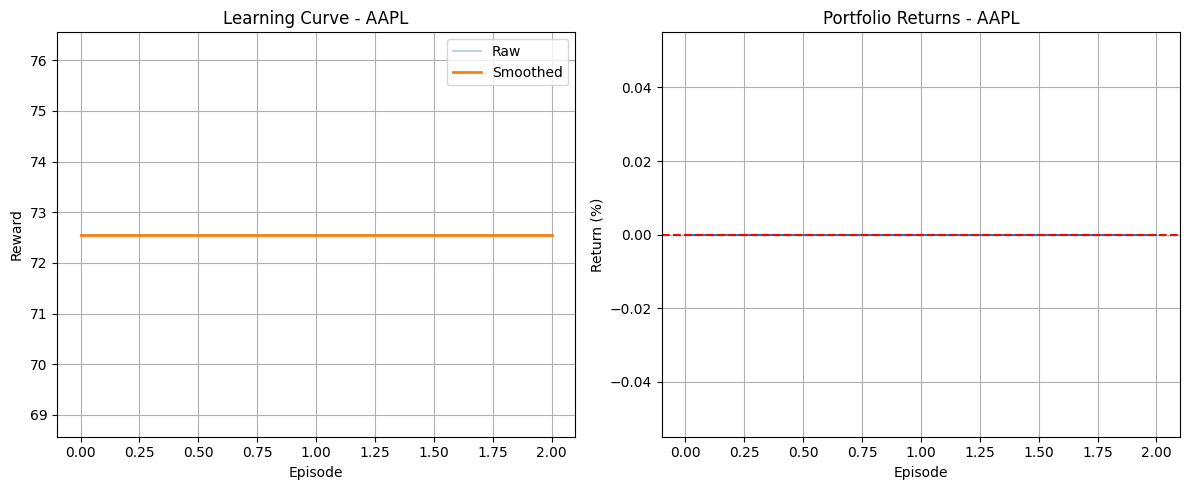

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing AMZN
Data loaded successfully for AMZN.
Training PPO Agent for AMZN...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2515 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2165        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004506287 |
|    clip_fraction        | 0.0276      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.219      |
|    learning_rate        | 0.0002      |
|    loss                 | 0.054       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00406    |
|    std          

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 37.87%
INFO:BacktesterRL:Buy & Hold Return: -0.92%
INFO:BacktesterRL:Outperformance: 38.79%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for AMZN ---
Total Return (%): 37.8700
Annual Return (%): 71.2000
Sharpe Ratio: 1.5858
Sortino Ratio: 2.6938
Max Drawdown (%): -21.6100
Calmar Ratio: 3.2949
Win Rate (%): 63.1600
Total Trades: 19.0000
Final Value ($): 137866.3500


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 30.02 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for AMZN ---
Total number of trades: 19

Trade Direction Counts:
Direction
Long    19
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 12
Number of loss exits (cut loss): 7
Win rate: 63.16%
Average profit per winning trade: $4938.49
Average loss per losing trade: $-3056.50
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for AMZN ---
Mean Episode Reward: 30.02
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


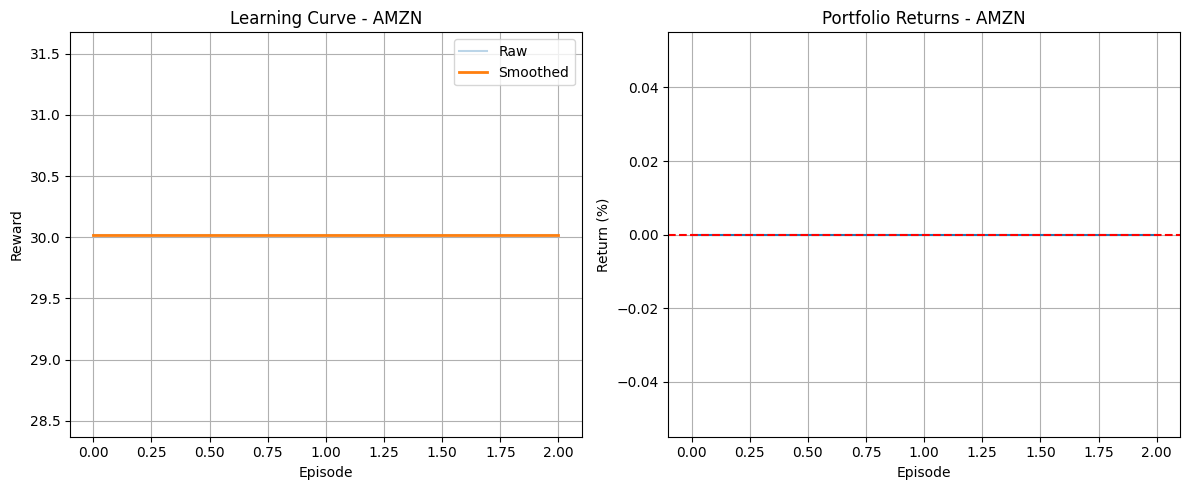

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing TSLA
Data loaded successfully for TSLA.
Training PPO Agent for TSLA...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2390 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2106        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.003404978 |
|    clip_fraction        | 0.0131      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.797      |
|    learning_rate        | 0.0002      |
|    loss                 | 0.0214      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00405    |
|    std          

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 189.04%
INFO:BacktesterRL:Buy & Hold Return: 0.02%
INFO:BacktesterRL:Outperformance: 189.01%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for TSLA ---
Total Return (%): 189.0400
Annual Return (%): 491.2600
Sharpe Ratio: 3.7910
Sortino Ratio: 9.7888
Max Drawdown (%): -15.3200
Calmar Ratio: 32.0703
Win Rate (%): 66.6700
Total Trades: 30.0000
Final Value ($): 289035.6000


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 136.55 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for TSLA ---
Total number of trades: 30

Trade Direction Counts:
Direction
Long    30
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 20
Number of loss exits (cut loss): 10
Win rate: 66.67%
Average profit per winning trade: $11851.43
Average loss per losing trade: $-4799.29
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for TSLA ---
Mean Episode Reward: 136.55
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


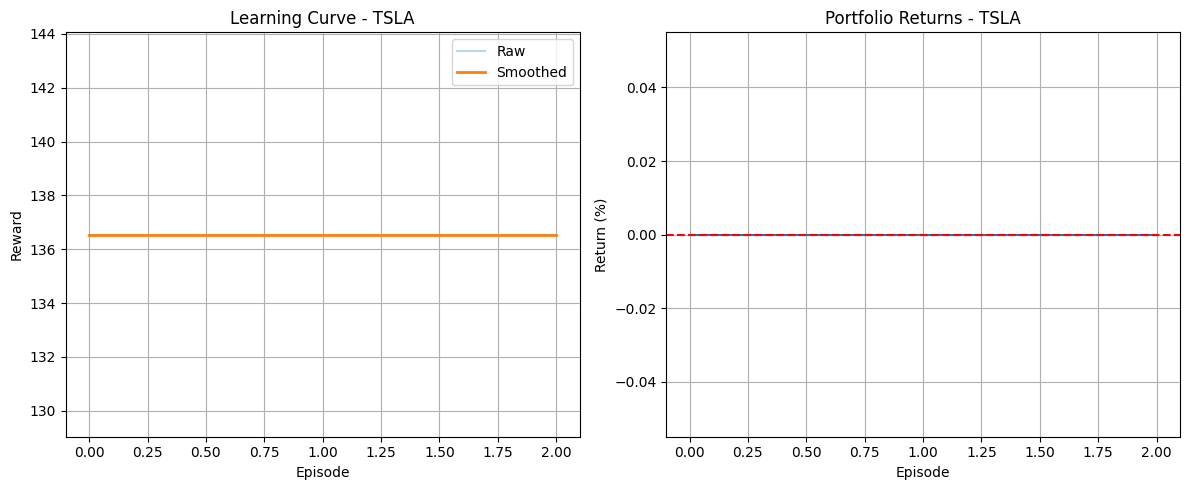

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing BAC
Data loaded successfully for BAC.
Training PPO Agent for BAC...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2506 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2142         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0037044752 |
|    clip_fraction        | 0.0146       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | -1.02        |
|    learning_rate        | 0.0002       |
|    loss                 | 0.0249       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0053      |
|    

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 54.51%
INFO:BacktesterRL:Buy & Hold Return: 14.96%
INFO:BacktesterRL:Outperformance: 39.55%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for BAC ---
Total Return (%): 54.5100
Annual Return (%): 107.1900
Sharpe Ratio: 4.1562
Sortino Ratio: 10.4159
Max Drawdown (%): -3.5700
Calmar Ratio: 30.0129
Win Rate (%): 96.4300
Total Trades: 28.0000
Final Value ($): 154509.0300


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 42.64 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for BAC ---
Total number of trades: 28

Trade Direction Counts:
Direction
Long    28
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 27
Number of loss exits (cut loss): 1
Win rate: 96.43%
Average profit per winning trade: $2025.45
Average loss per losing trade: $-178.19
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for BAC ---
Mean Episode Reward: 42.64
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


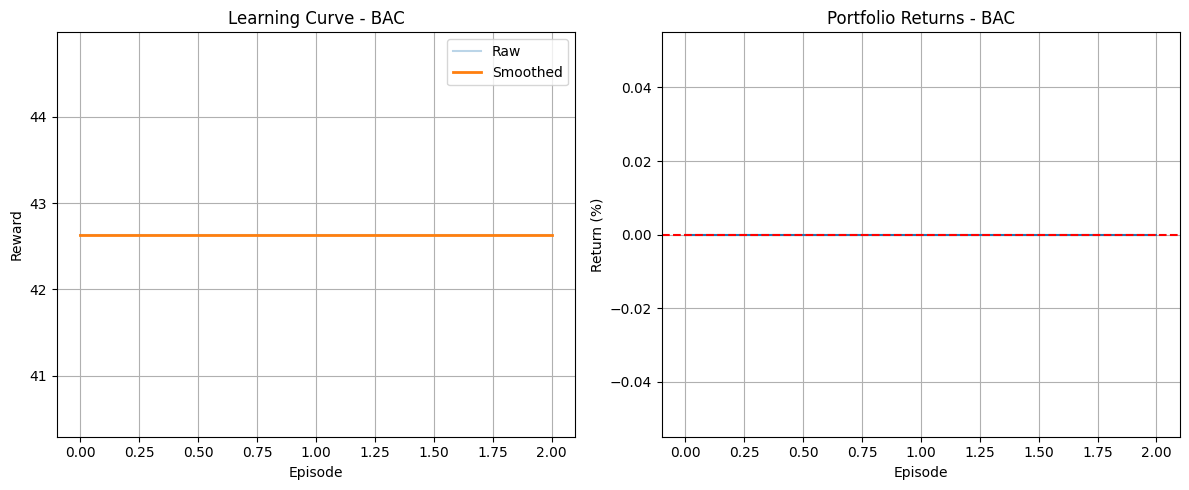

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing MDU
Data loaded successfully for MDU.
Training PPO Agent for MDU...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2411 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2135        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.003876288 |
|    clip_fraction        | 0.0215      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.137      |
|    learning_rate        | 0.0002      |
|    loss                 | -0.0172     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00562    |
|    std             

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 32.45%
INFO:BacktesterRL:Buy & Hold Return: 18.21%
INFO:BacktesterRL:Outperformance: 14.24%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for MDU ---
Total Return (%): 32.4500
Annual Return (%): 60.0900
Sharpe Ratio: 3.8655
Sortino Ratio: 8.8775
Max Drawdown (%): -2.6600
Calmar Ratio: 22.5783
Win Rate (%): 80.6500
Total Trades: 31.0000
Final Value ($): 132453.7000


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 32.79 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for MDU ---
Total number of trades: 31

Trade Direction Counts:
Direction
Long    31
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 25
Number of loss exits (cut loss): 6
Win rate: 80.65%
Average profit per winning trade: $1432.18
Average loss per losing trade: $-558.46
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for MDU ---
Mean Episode Reward: 32.79
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


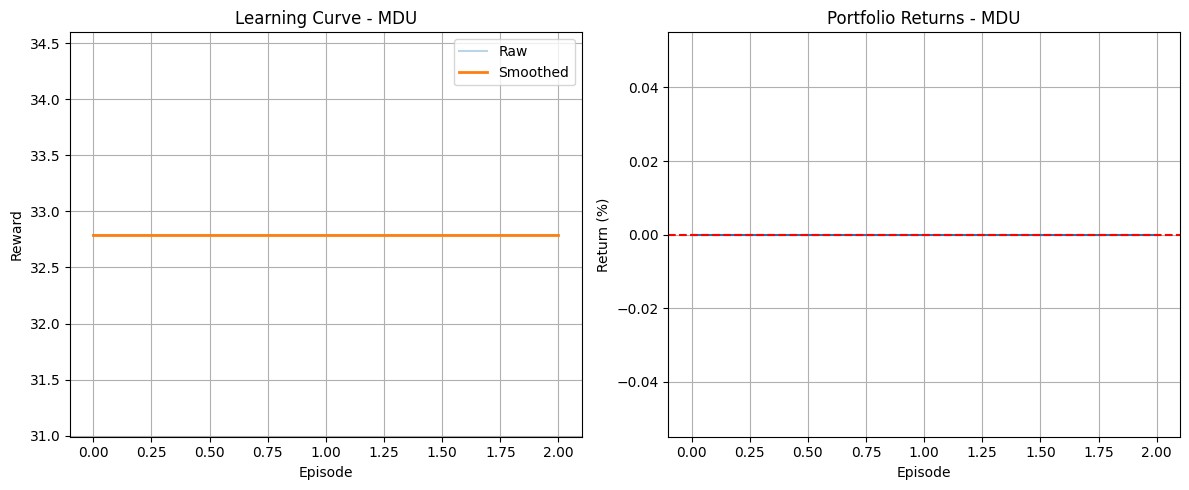

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing CWCO
Data loaded successfully for CWCO.
Training PPO Agent for CWCO...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2484 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2147         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0019698248 |
|    clip_fraction        | 0.00723      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | -0.721       |
|    learning_rate        | 0.0002       |
|    loss                 | 0.00949      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00183     |
| 

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 113.51%
INFO:BacktesterRL:Buy & Hold Return: 32.68%
INFO:BacktesterRL:Outperformance: 80.82%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for CWCO ---
Total Return (%): 113.5100
Annual Return (%): 256.0700
Sharpe Ratio: 4.7558
Sortino Ratio: 11.1456
Max Drawdown (%): -4.0100
Calmar Ratio: 63.8573
Win Rate (%): 86.9600
Total Trades: 23.0000
Final Value ($): 213507.0400


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 83.21 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for CWCO ---
Total number of trades: 23

Trade Direction Counts:
Direction
Long    23
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 20
Number of loss exits (cut loss): 3
Win rate: 86.96%
Average profit per winning trade: $5842.00
Average loss per losing trade: $-1110.99
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for CWCO ---
Mean Episode Reward: 83.21
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


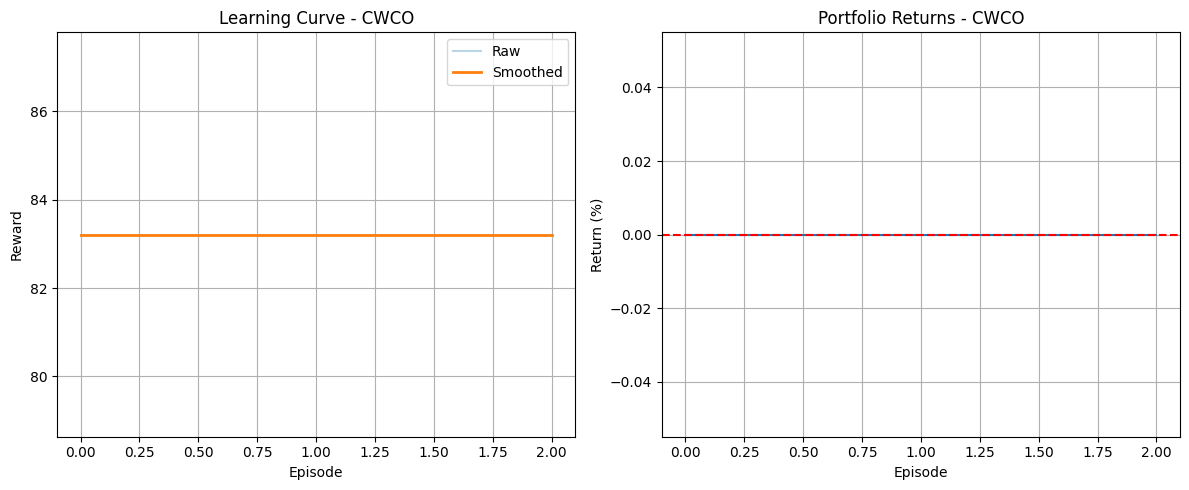

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing NEE
Data loaded successfully for NEE.
Training PPO Agent for NEE...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2414 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2104        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004602406 |
|    clip_fraction        | 0.0317      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.1        |
|    learning_rate        | 0.0002      |
|    loss                 | 0.0219      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00468    |
|    std             

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 115.68%
INFO:BacktesterRL:Buy & Hold Return: 28.02%
INFO:BacktesterRL:Outperformance: 87.66%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for NEE ---
Total Return (%): 115.6800
Annual Return (%): 262.1600
Sharpe Ratio: 5.8314
Sortino Ratio: 15.5777
Max Drawdown (%): -3.9400
Calmar Ratio: 66.5140
Win Rate (%): 70.0000
Total Trades: 30.0000
Final Value ($): 215678.5600


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 75.39 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for NEE ---
Total number of trades: 30

Trade Direction Counts:
Direction
Long    30
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 21
Number of loss exits (cut loss): 9
Win rate: 70.00%
Average profit per winning trade: $5994.77
Average loss per losing trade: $-1134.62
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for NEE ---
Mean Episode Reward: 75.39
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


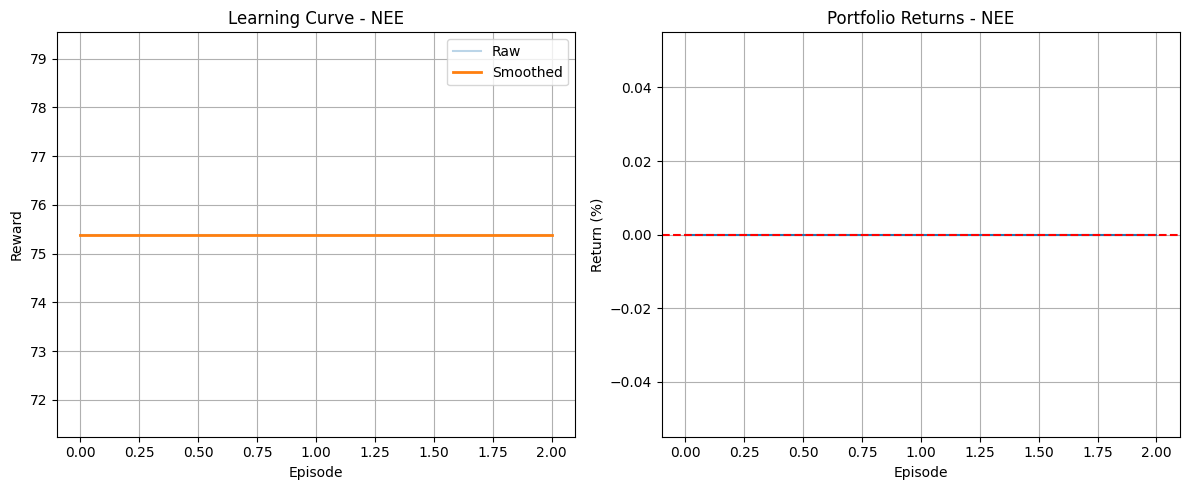

C:\Users\BOOKLAPTOP\AppData\Local\Temp\ipykernel_10084\432317138.py:35: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO...



Processing DUK
Data loaded successfully for DUK.
Training PPO Agent for DUK...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2397 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2124        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004632909 |
|    clip_fraction        | 0.0282      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.246       |
|    learning_rate        | 0.0002      |
|    loss                 | 0.0971      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00462    |
|    std             

INFO:src.models.model_trainer_rl_v2_2_buyhold:Training PPO for 200000 timesteps
INFO:BacktesterRL:Preparing Backtest. Raw Prices: 279, Predictions: 218
INFO:BacktesterRL:Running vectorbt simulation...
INFO:BacktesterRL:Backtest successfully completed.
INFO:BacktesterRL:Strategy Return: 28.49%
INFO:BacktesterRL:Buy & Hold Return: 19.81%
INFO:BacktesterRL:Outperformance: 8.68%


Saved model and normalization stats for models/ppo_vecnormalize.pkl
Training Complete. Models saved.
Generating Agent Predictions on Test Data...
Generated 218 actions.
Running Backtest...

--- Strategy Performance for DUK ---
Total Return (%): 28.4900
Annual Return (%): 52.1500
Sharpe Ratio: 2.3276
Sortino Ratio: 3.6135
Max Drawdown (%): -5.0600
Calmar Ratio: 10.2984
Win Rate (%): 100.0000
Total Trades: 7.0000
Final Value ($): 128488.9100


INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:RL AGENT PERFORMANCE METRICS SUMMARY
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================
INFO:src.models.model_trainer_rl_v2_2_buyhold:Total Episodes: 3
INFO:src.models.model_trainer_rl_v2_2_buyhold:Mean Episode Reward: 30.82 ± 0.00
INFO:src.models.model_trainer_rl_v2_2_buyhold:Success Rate: 0.0%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Learning Improvement: 0.00 (0.0%)
INFO:src.models.model_trainer_rl_v2_2_buyhold:Trend Slope: 0.0000
INFO:src.models.model_trainer_rl_v2_2_buyhold:Stability (CV): 0.00%
INFO:src.models.model_trainer_rl_v2_2_buyhold:Portfolio Sharpe Ratio: 0.000
INFO:src.models.model_trainer_rl_v2_2_buyhold:============================================================



--- Trade Statistics for DUK ---
Total number of trades: 7

Trade Direction Counts:
Direction
Long    7
Name: count, dtype: int64

--- Trade Outcomes ---
Number of profitable exits: 7
Number of loss exits (cut loss): 0
Win rate: 100.00%
Average profit per winning trade: $4069.84
No losing trades
Evaluating RL performance metrics...
[EP 0] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 1] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218
[EP 2] total_asset=100000.00, initial_balance=100000.00, return=0.000000, steps=218

--- RL Metrics Summary for DUK ---
Mean Episode Reward: 30.82
Success Rate: 0.0%
Sharpe Ratio: 0.000
Learning Improvement: 0.00


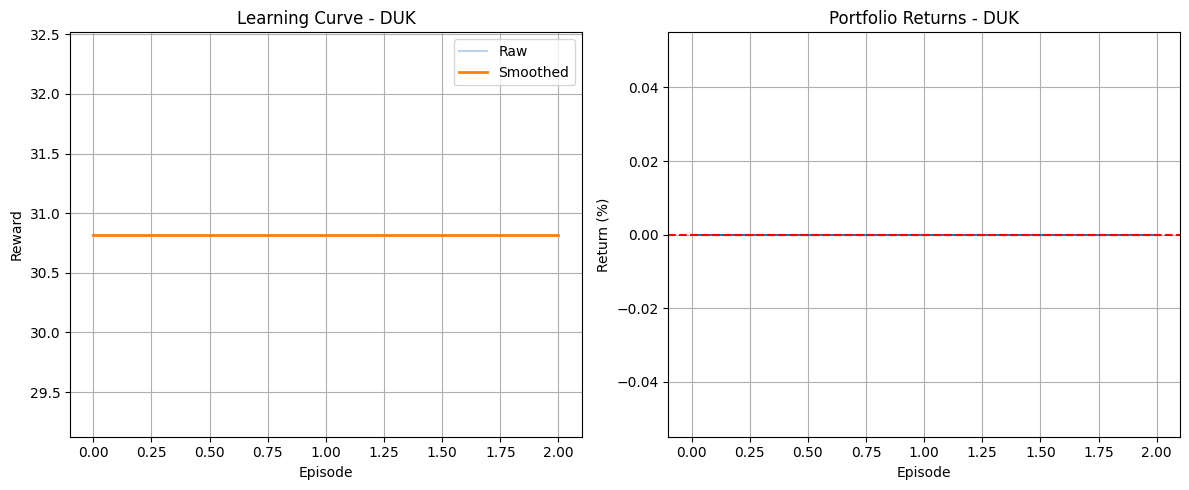

In [5]:
# Multiple stocks in a loop
stocks = ["AAPL", "AMZN", "TSLA", "BAC","MDU", "CWCO", "NEE", "DUK"]
results = {}

for stock in stocks:
    print(f"\n{'='*60}")
    print(f"Processing {stock}")
    print(f"{'='*60}")
    portfolio, metrics, actions, rl_metrics, learning_curve_data = run_ppo_trading_pipeline(
        stock_symbol=stock, 
        config=config,
        show_plot=True  # Don't show plots in loop
    )
    results[stock] = {
        'portfolio': portfolio,
        'metrics': metrics,
        'actions': actions,
        'rl_metrics': rl_metrics,
        'learning_curve_data': learning_curve_data
    }